# Project Phase 1
# Name : Maulik Sindhva
# Student id : 2434771

In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Running on device: {device}')

Running on device: cuda:0


In [12]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import torch
import torchvision.models as models

## Dataset Loading with split

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # or (28,28) if needed
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(
    root="animal_10/raw-img",
    transform=transform)

In [8]:
total_len = len(dataset)
train_size = int(0.7 * total_len)
val_size = int(0.15 * total_len)
test_size = total_len - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# This cell is redundant as dataloaders are already defined in a previous cell.
# The val_loader was not defined here, which is necessary for evaluation.
# Removed to ensure consistency and correct usage of train, val, and test loaders.

## Training , evaluation and testing loops

In [10]:
def train_model(model, train_loader, criterion, optimizer):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() #loss.item() converts the PyTorch tensor into a Python float
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()  #.sum().item() counts correct predictions for this batch and converts to Python int.

    return running_loss / len(train_loader), 100 * correct / total


def evaluate_model(model, val_loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return running_loss / len(val_loader), 100 * correct / total

def get_predictions(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds



In [13]:
criterion = nn.CrossEntropyLoss()

## MobileNet

In [15]:
mobilenet = models.mobilenet_v2(weights=None)
mobilenet.classifier[1] = nn.Linear(1280, 10)
mobilenet = mobilenet.to(device)

# Initialize optimizer for MobileNet
optimizer_mobilenet = optim.Adam(mobilenet.parameters(), lr=0.0005)

train_losses_mobilenet, val_losses_mobilenet = [], []
train_accuracies_mobilenet, val_accuracies_mobilenet = [], []
test_accuracies_mobilenet = [] # New list to store test accuracies

for epoch in range(10):
    train_loss, train_acc = train_model(mobilenet, train_loader, criterion, optimizer_mobilenet)
    val_loss, val_acc = evaluate_model(mobilenet, val_loader, criterion)
    _, test_acc = evaluate_model(mobilenet, test_loader, criterion) # Evaluate on test set

    train_losses_mobilenet.append(train_loss)
    val_losses_mobilenet.append(val_loss)
    train_accuracies_mobilenet.append(train_acc)
    val_accuracies_mobilenet.append(val_acc)
    test_accuracies_mobilenet.append(test_acc) # Store test accuracy

    print(f"Epoch {epoch+1}: "
          f"Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%, Test Acc={test_acc:.2f}%")

torch.save(mobilenet.state_dict(), "mobilenet_animals.pth")

Epoch 1: Train Acc=37.83%, Val Acc=46.08%, Test Acc=46.44%
Epoch 2: Train Acc=52.43%, Val Acc=56.85%, Test Acc=55.02%
Epoch 3: Train Acc=60.10%, Val Acc=61.59%, Test Acc=59.88%
Epoch 4: Train Acc=66.47%, Val Acc=67.24%, Test Acc=65.17%
Epoch 5: Train Acc=70.47%, Val Acc=68.47%, Test Acc=65.84%
Epoch 6: Train Acc=74.82%, Val Acc=67.01%, Test Acc=66.09%
Epoch 7: Train Acc=77.96%, Val Acc=71.12%, Test Acc=70.67%
Epoch 8: Train Acc=80.87%, Val Acc=71.40%, Test Acc=69.04%
Epoch 9: Train Acc=83.65%, Val Acc=74.04%, Test Acc=73.45%
Epoch 10: Train Acc=86.15%, Val Acc=75.60%, Test Acc=74.47%


In [21]:
# Load the trained model
mobilenet.load_state_dict(torch.load("mobilenet_animals.pth"))
mobilenet.eval()

# Get true labels and predictions
y_true_1, y_pred_1 = get_predictions(mobilenet, test_loader)

# Print classification report
print("MobileNet Metrics:\n")
print(classification_report(y_true_1, y_pred_1, target_names=dataset.classes))

MobileNet Metrics:

              precision    recall  f1-score   support

        cane       0.68      0.80      0.73       740
     cavallo       0.73      0.74      0.74       381
    elefante       0.75      0.56      0.64       226
    farfalla       0.80      0.84      0.82       315
     gallina       0.87      0.85      0.86       469
       gatto       0.64      0.56      0.60       261
       mucca       0.64      0.65      0.64       280
      pecora       0.66      0.64      0.65       276
       ragno       0.89      0.81      0.85       713
  scoiattolo       0.63      0.67      0.65       267

    accuracy                           0.74      3928
   macro avg       0.73      0.71      0.72      3928
weighted avg       0.75      0.74      0.74      3928



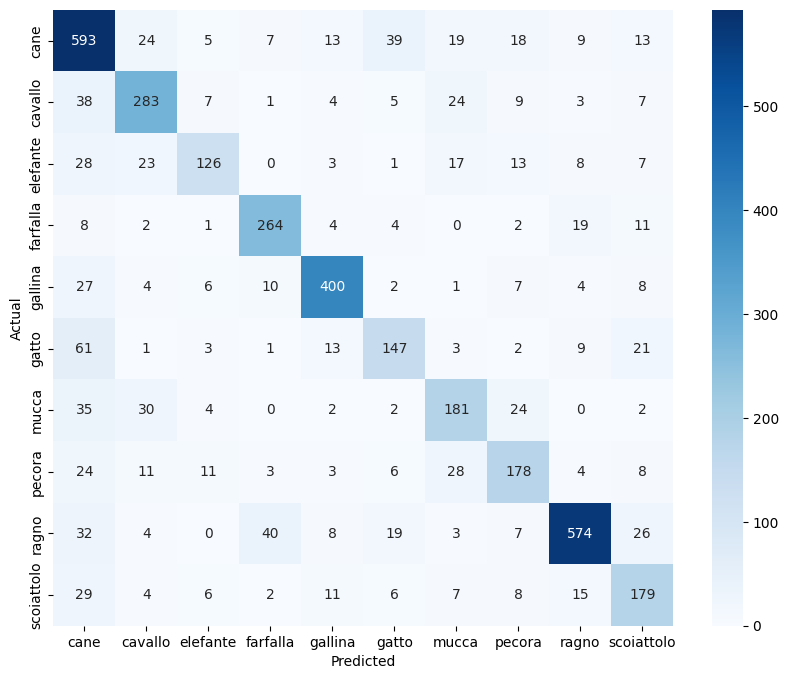

In [23]:
cm = confusion_matrix(y_true_1, y_pred_1)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.classes,
            yticklabels=dataset.classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## ShuffleNet

In [17]:
shufflenet = models.shufflenet_v2_x1_0(weights=None)
shufflenet.fc = nn.Linear(1024, 10)
shufflenet = shufflenet.to(device)

# Initialize optimizer for ShuffleNet
optimizer_shufflenet = optim.Adam(shufflenet.parameters(), lr=0.001)

train_losses_shufflenet, val_losses_shufflenet = [], []
train_accuracies_shufflenet, val_accuracies_shufflenet = [], []
test_accuracies_shufflenet = [] # New list to store test accuracies

for epoch in range(10):
    train_loss, train_acc = train_model(shufflenet, train_loader, criterion, optimizer_shufflenet)
    val_loss, val_acc = evaluate_model(shufflenet, val_loader, criterion)
    _, test_acc = evaluate_model(shufflenet, test_loader, criterion) # Evaluate on test set

    train_losses_shufflenet.append(train_loss)
    val_losses_shufflenet.append(val_loss)
    train_accuracies_shufflenet.append(train_acc)
    val_accuracies_shufflenet.append(val_acc)
    test_accuracies_shufflenet.append(test_acc) # Store test accuracy

    print(f"Epoch {epoch+1}: "
          f"Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%, Test Acc={test_acc:.2f}%")

torch.save(shufflenet.state_dict(), "shufflenet_animals.pth")

Epoch 1: Train Acc=38.36%, Val Acc=46.99%, Test Acc=44.63%
Epoch 2: Train Acc=55.44%, Val Acc=48.88%, Test Acc=47.61%
Epoch 3: Train Acc=63.53%, Val Acc=65.77%, Test Acc=64.46%
Epoch 4: Train Acc=68.85%, Val Acc=67.88%, Test Acc=67.29%
Epoch 5: Train Acc=72.70%, Val Acc=66.58%, Test Acc=66.32%
Epoch 6: Train Acc=76.26%, Val Acc=69.56%, Test Acc=69.32%
Epoch 7: Train Acc=79.30%, Val Acc=71.60%, Test Acc=72.71%
Epoch 8: Train Acc=81.68%, Val Acc=70.76%, Test Acc=72.17%
Epoch 9: Train Acc=84.83%, Val Acc=68.57%, Test Acc=68.69%
Epoch 10: Train Acc=86.99%, Val Acc=72.72%, Test Acc=72.25%


In [18]:
# Load the trained model
shufflenet.load_state_dict(torch.load("shufflenet_animals.pth"))
shufflenet.eval()

# Get true labels and predictions
y_true, y_pred = get_predictions(shufflenet, test_loader)

# Print classification report
print("ShuffleNet Metrics:\n")
print(classification_report(y_true, y_pred, target_names=dataset.classes))

ShuffleNet Metrics:

              precision    recall  f1-score   support

        cane       0.61      0.81      0.69       740
     cavallo       0.75      0.73      0.74       381
    elefante       0.72      0.64      0.68       226
    farfalla       0.83      0.71      0.76       315
     gallina       0.83      0.80      0.81       469
       gatto       0.72      0.46      0.57       261
       mucca       0.62      0.58      0.60       280
      pecora       0.65      0.62      0.63       276
       ragno       0.86      0.82      0.84       713
  scoiattolo       0.65      0.65      0.65       267

    accuracy                           0.72      3928
   macro avg       0.72      0.68      0.70      3928
weighted avg       0.73      0.72      0.72      3928



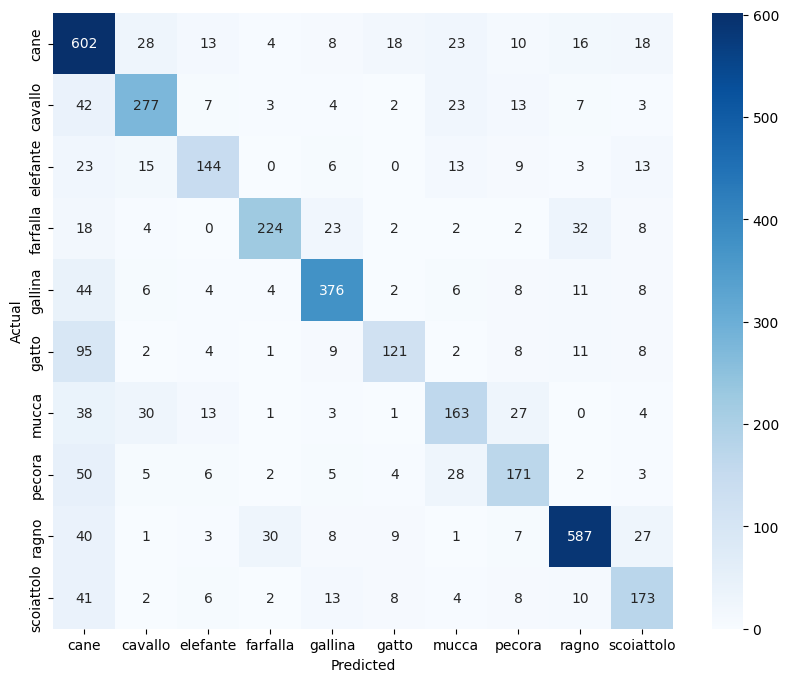

In [19]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.classes,
            yticklabels=dataset.classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

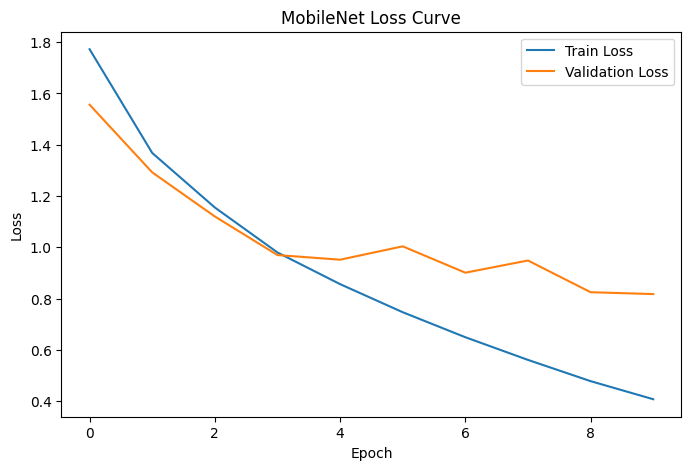

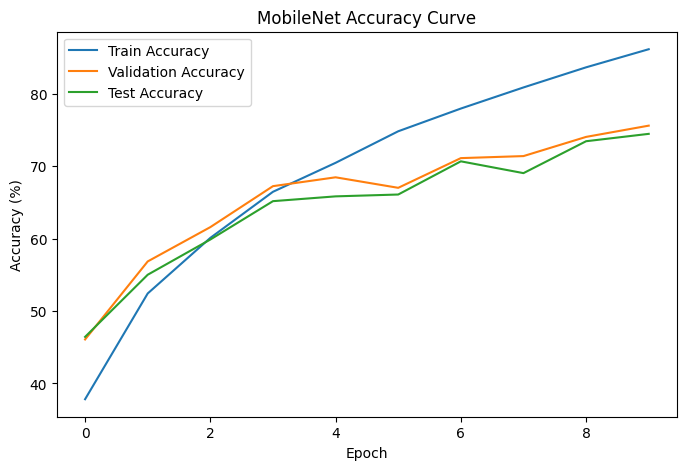

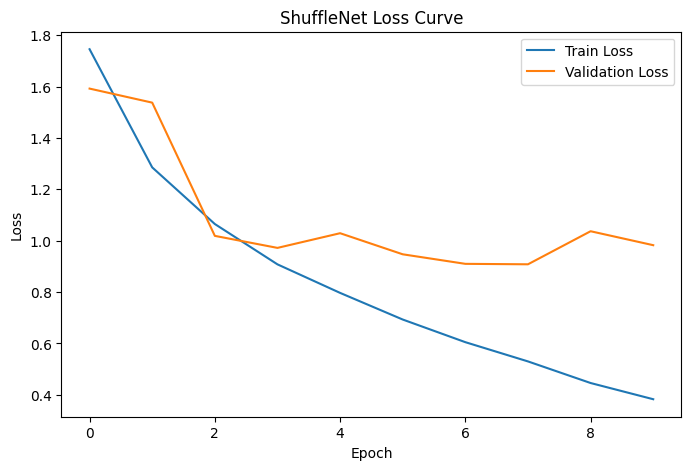

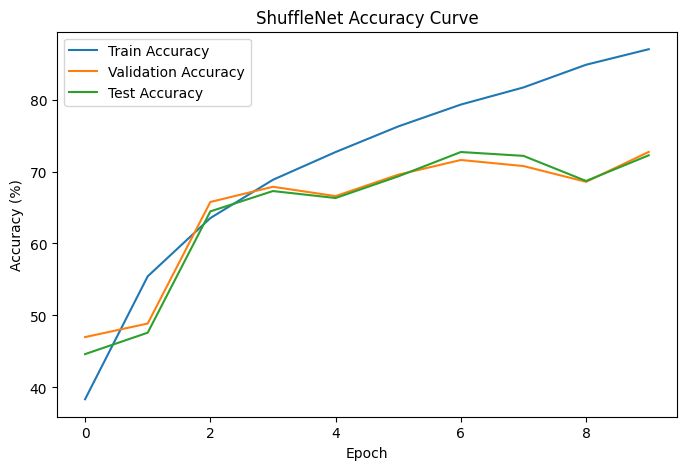

In [20]:
def plot_curves(train_losses, val_losses, train_acc, val_acc, test_acc, model_name):
    # Loss
    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f'{model_name} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure(figsize=(8,5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.plot(test_acc, label='Test Accuracy') # Plot test accuracy
    plt.title(f'{model_name} Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.show()

plot_curves(train_losses_mobilenet, val_losses_mobilenet, train_accuracies_mobilenet, val_accuracies_mobilenet, test_accuracies_mobilenet, "MobileNet")
plot_curves(train_losses_shufflenet, val_losses_shufflenet, train_accuracies_shufflenet, val_accuracies_shufflenet, test_accuracies_shufflenet, "ShuffleNet")